# TextBlob vs FinBERT: Análisis de Sentimiento en Noticias Financieras

Este notebook compara dos enfoques para análisis de sentimiento aplicados a noticias financieras:

| Modelo | Tipo | Entrenamiento |
|--------|------|---------------|
| **TextBlob** | Léxico basado en reglas | Corpus general (no financiero) |
| **FinBERT** | Transformer (BERT fine-tuned) | 10K reportes financieros de EE.UU. |

**Hipótesis**: el lenguaje financiero tiene semántica específica que un léxico general no captura.
Por ejemplo: _"La empresa reportó pérdidas menores a las esperadas"_ → **positivo** en finanzas (beat expectations), pero negativo para TextBlob.

In [ ]:
x = 42
x.__class__

x = ["foo", "bar"]
callable(x.append)

# print a list of methods of the boolean object True.

print(dir(True))
import rich

rich.inspect(True, methods=True)

['__abs__', '__add__', '__and__', '__bool__', '__ceil__', '__class__', '__delattr__', '__dir__', '__divmod__', '__doc__', '__eq__', '__float__', '__floor__', '__floordiv__', '__format__', '__ge__', '__getattribute__', '__getnewargs__', '__getstate__', '__gt__', '__hash__', '__index__', '__init__', '__init_subclass__', '__int__', '__invert__', '__le__', '__lshift__', '__lt__', '__mod__', '__mul__', '__ne__', '__neg__', '__new__', '__or__', '__pos__', '__pow__', '__radd__', '__rand__', '__rdivmod__', '__reduce__', '__reduce_ex__', '__repr__', '__rfloordiv__', '__rlshift__', '__rmod__', '__rmul__', '__ror__', '__round__', '__rpow__', '__rrshift__', '__rshift__', '__rsub__', '__rtruediv__', '__rxor__', '__setattr__', '__sizeof__', '__str__', '__sub__', '__subclasshook__', '__truediv__', '__trunc__', '__xor__', 'as_integer_ratio', 'bit_count', 'bit_length', 'conjugate', 'denominator', 'from_bytes', 'imag', 'numerator', 'real', 'to_bytes']


╭──────────────────────────────────────────────── <class 'bool'> ─────────────────────────────────────────────────╮
│ bool(x) -> bool                                                                                                 │
│                                                                                                                 │
│ ╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────╮ │
│ │ True                                                                                                        │ │
│ ╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────╯ │
│                                                                                                                 │
│      denominator = 1                                                                                            │
│             imag = 0                                                                                            │
│        numerator = 1                                                                                            │
│             real = 1                                                                                            │
│ as_integer_ratio = def as_integer_ratio(): Return integer ratio.                                                │
│        bit_count = def bit_count(): Number of ones in the binary representation of the absolute value of self.  │
│       bit_length = def bit_length(): Number of bits necessary to represent self in binary.                      │
│        conjugate = def conjugate(...) Returns self, the complex conjugate of any int.                           │
│       from_bytes = def from_bytes(bytes, byteorder='big', *, signed=False): Return the integer represented by   │
│                    the given array of bytes.                                                                    │
│         to_bytes = def to_bytes(length=1, byteorder='big', *, signed=False): Return an array of bytes           │
│                    representing an integer.                                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## 1. Instalación de dependencias

In [ ]:
# Solo ejecutar si no están instalados
# !pip install textblob transformers torch pandas matplotlib seaborn

## 2. Dataset de prueba

Diseñamos casos que desafían a un modelo de lenguaje general:
- **Eufemismos financieros**: "pérdidas menores a las esperadas" = positivo
- **Contexto de mercado**: "volatilidad" puede ser positivo para traders
- **Negaciones complejas**: "no tan malo como se temía"
- **Jerga financiera**: "rally", "sell-off", "corrección"

In [3]:
import pandas as pd

# Cada ejemplo tiene la etiqueta esperada según contexto financiero
examples = [
    # Casos donde TextBlob debería fallar (semántica financiera específica)
    {
        "text": "The company reported losses smaller than expected, beating analyst estimates.",
        "ticker": "AAPL",
        "expected": "positive",
        "reason": "Beat expectations → positivo en finanzas, 'losses' confunde a TextBlob",
    },
    {
        "text": "Stocks fell sharply as the Fed announced another rate hike, but markets recovered quickly.",
        "ticker": "SPY",
        "expected": "positive",
        "reason": "Recuperación rápida es la señal relevante",
    },
    {
        "text": "The merger deal collapsed, wiping out $2 billion in shareholder value.",
        "ticker": "MSFT",
        "expected": "negative",
        "reason": "Destrucción de valor clara",
    },
    {
        "text": "Revenue declined 3%, but gross margin improved significantly, signaling operational efficiency.",
        "ticker": "GOOGL",
        "expected": "positive",
        "reason": "Mejora de márgenes compensa caída de revenue",
    },
    {
        "text": "The stock experienced a massive sell-off following disappointing guidance.",
        "ticker": "META",
        "expected": "negative",
        "reason": "Sell-off + guidance decepcionante",
    },
    {
        "text": "Earnings per share missed consensus by 2 cents, sending shares down 8% after hours.",
        "ticker": "AMZN",
        "expected": "negative",
        "reason": "Miss de EPS con caída significativa",
    },
    {
        "text": "The company raised its full-year outlook, citing strong demand across all business segments.",
        "ticker": "NVDA",
        "expected": "positive",
        "reason": "Guidance raised es señal alcista clara",
    },
    {
        "text": "The restructuring will result in layoffs of 5,000 employees but is expected to improve profitability.",
        "ticker": "IBM",
        "expected": "neutral",
        "reason": "Señal mixta: negativo social, positivo para inversores",
    },
    {
        "text": "Inflation data came in hotter than expected, raising fears of prolonged monetary tightening.",
        "ticker": "TLT",
        "expected": "negative",
        "reason": "Inflación alta es negativa para bonos",
    },
    {
        "text": "The IPO was oversubscribed 10 times, reflecting strong investor appetite for growth stocks.",
        "ticker": "NEW",
        "expected": "positive",
        "reason": "Demanda masiva en IPO es señal positiva",
    },
    # Casos argentinos / mercado local
    {
        "text": "YPF reportó ganancias récord impulsadas por el aumento del precio del crudo y la devaluación.",
        "ticker": "YPF",
        "expected": "positive",
        "reason": "Ganancias récord claramente positivo",
    },
    {
        "text": "Mercado Libre superó expectativas con un crecimiento del 30% en volumen de pagos.",
        "ticker": "MELI",
        "expected": "positive",
        "reason": "Superó expectativas + crecimiento fuerte",
    },
]

df = pd.DataFrame(examples)
print(f"Total de ejemplos: {len(df)}")

df[["ticker", "expected", "reason", "text"]]

Total de ejemplos: 12


,ticker,expected,reason,text
0,AAPL,positive,"Beat expectations → positivo en finanzas, 'los...",The company reported losses smaller than expec...
1,SPY,positive,Recuperación rápida es la señal relevante,Stocks fell sharply as the Fed announced anoth...
2,MSFT,negative,Destrucción de valor clara,"The merger deal collapsed, wiping out $2 billi..."
3,GOOGL,positive,Mejora de márgenes compensa caída de revenue,"Revenue declined 3%, but gross margin improved..."
4,META,negative,Sell-off + guidance decepcionante,The stock experienced a massive sell-off follo...
5,AMZN,negative,Miss de EPS con caída significativa,Earnings per share missed consensus by 2 cents...
6,NVDA,positive,Guidance raised es señal alcista clara,"The company raised its full-year outlook, citi..."
7,IBM,neutral,"Señal mixta: negativo social, positivo para in...","The restructuring will result in layoffs of 5,..."
8,TLT,negative,Inflación alta es negativa para bonos,"Inflation data came in hotter than expected, r..."
9,NEW,positive,Demanda masiva en IPO es señal positiva,"The IPO was oversubscribed 10 times, reflectin..."


## 3. TextBlob (línea de base)

In [4]:
from textblob import TextBlob


def textblob_sentiment(text: str) -> tuple[str, float]:
    score = TextBlob(text).sentiment.polarity
    if score > 0.05:
        label = "positive"
    elif score < -0.05:
        label = "negative"
    else:
        label = "neutral"
    return label, round(score, 4)


df["textblob_label"], df["textblob_score"] = zip(*df["text"].map(textblob_sentiment))
df["textblob_correct"] = df["textblob_label"] == df["expected"]

print(f"TextBlob accuracy: {df['textblob_correct'].mean():.1%}")
df[["ticker", "expected", "textblob_label", "textblob_score", "textblob_correct"]]

TextBlob accuracy: 50.0%


,ticker,expected,textblob_label,textblob_score,textblob_correct
0,AAPL,positive,neutral,-0.0500,False
1,SPY,positive,positive,0.1042,True
2,MSFT,negative,neutral,0.0000,False
3,GOOGL,positive,positive,0.1875,True
4,META,negative,positive,0.0500,False
5,AMZN,negative,negative,-0.1556,True
6,NVDA,positive,positive,0.4333,True
7,IBM,neutral,negative,-0.1000,False
8,TLT,negative,negative,-0.1000,True
9,NEW,positive,positive,0.4333,True


## 4. FinBERT

[ProsusAI/finbert](https://huggingface.co/ProsusAI/finbert) es BERT fine-tuned sobre ~10.000 frases de reportes financieros de Guidance Financial News, con etiquetas `positive`, `negative`, `neutral`.

In [6]:
from transformers import pipeline

# Carga el modelo (primera vez descarga ~400MB)
finbert = pipeline(
    "text-classification",
    model="ProsusAI/finbert",
    tokenizer="ProsusAI/finbert",
    top_k=None,  # devuelve scores para todas las clases
)

print("FinBERT cargado correctamente")

/Users/carbonecar/maestria_ia/nlp/trabajo_practico/asistente_financiero/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 66618.34it/s]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FinBERT cargado correctamente


In [7]:
def finbert_sentiment(text: str) -> tuple[str, float]:
    # FinBERT trunca a 512 tokens automáticamente
    results = finbert(text[:512])[0]  # lista de {label, score}
    best = max(results, key=lambda x: x["score"])
    label = best["label"].lower()
    # Convertir a score numérico [-1, 1] para comparar con TextBlob
    score_map = {"positive": best["score"], "negative": -best["score"], "neutral": 0.0}
    return label, round(score_map[label], 4)


df["finbert_label"], df["finbert_score"] = zip(*df["text"].map(finbert_sentiment))
df["finbert_correct"] = df["finbert_label"] == df["expected"]

print(f"FinBERT accuracy: {df['finbert_correct'].mean():.1%}")
df[["ticker", "expected", "finbert_label", "finbert_score", "finbert_correct"]]

FinBERT accuracy: 66.7%


,ticker,expected,finbert_label,finbert_score,finbert_correct
0,AAPL,positive,positive,0.5485,True
1,SPY,positive,negative,-0.7883,False
2,MSFT,negative,negative,-0.9486,True
3,GOOGL,positive,positive,0.8417,True
4,META,negative,negative,-0.9678,True
5,AMZN,negative,negative,-0.9733,True
6,NVDA,positive,positive,0.9538,True
7,IBM,neutral,positive,0.9129,False
8,TLT,negative,negative,-0.8634,True
9,NEW,positive,positive,0.7526,True


## 5. Comparación lado a lado

In [8]:
comparison = df[
    ["ticker", "expected", "textblob_label", "textblob_correct", "finbert_label", "finbert_correct", "reason"]
].copy()

# Marcar donde difieren
comparison["models_agree"] = comparison["textblob_label"] == comparison["finbert_label"]

print("=== Resumen ===")
print(f"TextBlob correctos:  {comparison['textblob_correct'].sum()}/{len(comparison)}")
print(f"FinBERT correctos:   {comparison['finbert_correct'].sum()}/{len(comparison)}")
print(f"Acuerdo entre modelos: {comparison['models_agree'].sum()}/{len(comparison)}")
print()

# Casos donde difieren
print("=== Casos donde los modelos difieren ===")
diff = comparison[~comparison["models_agree"]][["ticker", "expected", "textblob_label", "finbert_label", "reason"]]
diff

=== Resumen ===
TextBlob correctos:  6/12
FinBERT correctos:   8/12
Acuerdo entre modelos: 7/12

=== Casos donde los modelos difieren ===


,ticker,expected,textblob_label,finbert_label,reason
0,AAPL,positive,neutral,positive,"Beat expectations → positivo en finanzas, 'los..."
1,SPY,positive,positive,negative,Recuperación rápida es la señal relevante
2,MSFT,negative,neutral,negative,Destrucción de valor clara
4,META,negative,positive,negative,Sell-off + guidance decepcionante
7,IBM,neutral,negative,positive,"Señal mixta: negativo social, positivo para in..."


## 6. Visualizaciones

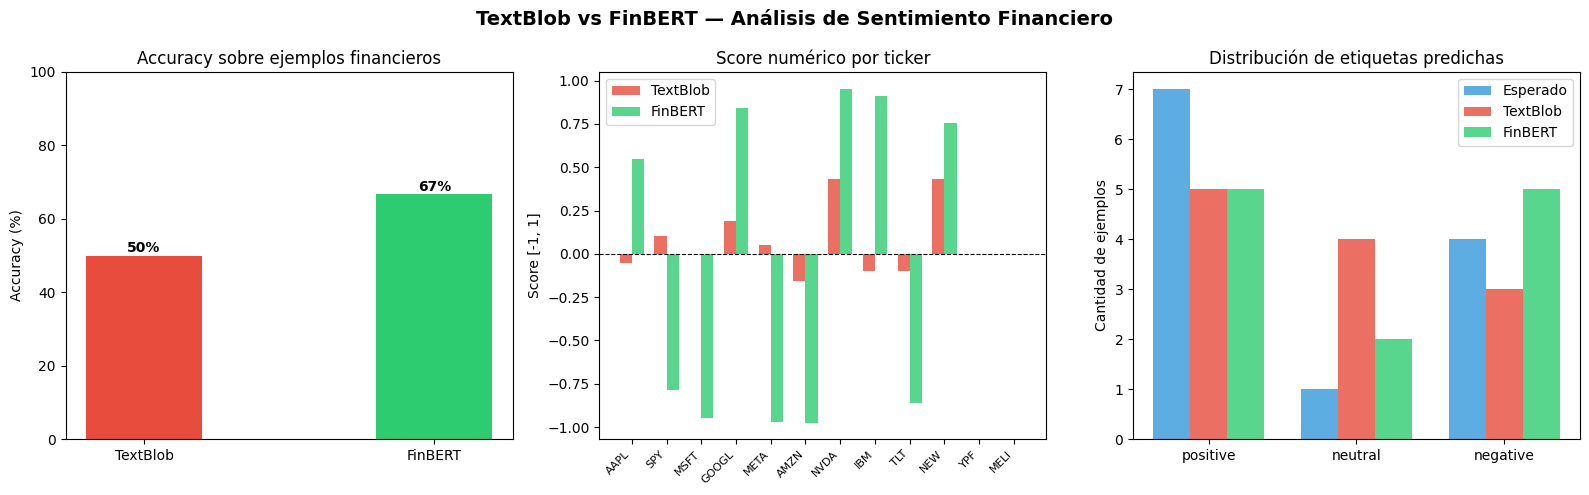

Gráfico guardado como textblob_vs_finbert.png


In [10]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("TextBlob vs FinBERT — Análisis de Sentimiento Financiero", fontsize=14, fontweight="bold")

# --- Plot 1: Accuracy comparada ---
ax = axes[0]
models = ["TextBlob", "FinBERT"]
accuracies = [df["textblob_correct"].mean(), df["finbert_correct"].mean()]
colors = ["#e74c3c", "#2ecc71"]
bars = ax.bar(models, [a * 100 for a in accuracies], color=colors, width=0.4)
ax.set_ylim(0, 100)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy sobre ejemplos financieros")
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f"{acc:.0%}", ha="center", fontweight="bold")

# --- Plot 2: Score numérico por ejemplo ---
ax = axes[1]
x = np.arange(len(df))
width = 0.35
ax.bar(x - width / 2, df["textblob_score"], width, label="TextBlob", color="#e74c3c", alpha=0.8)
ax.bar(x + width / 2, df["finbert_score"], width, label="FinBERT", color="#2ecc71", alpha=0.8)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(df["ticker"], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Score [-1, 1]")
ax.set_title("Score numérico por ticker")
ax.legend()

# --- Plot 3: Matriz de confusión por modelo ---
ax = axes[2]
categories = ["positive", "neutral", "negative"]
tb_dist = df["textblob_label"].value_counts().reindex(categories, fill_value=0)
fb_dist = df["finbert_label"].value_counts().reindex(categories, fill_value=0)
exp_dist = df["expected"].value_counts().reindex(categories, fill_value=0)

x = np.arange(len(categories))
width = 0.25
ax.bar(x - width, exp_dist.values, width, label="Esperado", color="#3498db", alpha=0.8)
ax.bar(x, tb_dist.values, width, label="TextBlob", color="#e74c3c", alpha=0.8)
ax.bar(x + width, fb_dist.values, width, label="FinBERT", color="#2ecc71", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel("Cantidad de ejemplos")
ax.set_title("Distribución de etiquetas predichas")
ax.legend()

plt.tight_layout()
plt.savefig("textblob_vs_finbert.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado como textblob_vs_finbert.png")

## 7. Análisis de errores de TextBlob

In [11]:
print("=== Errores de TextBlob que FinBERT corrige ===")
tb_wrong_fb_right = df[(~df["textblob_correct"]) & df["finbert_correct"]]

for _, row in tb_wrong_fb_right.iterrows():
    print(f"\n[{row['ticker']}] Esperado: {row['expected']}")
    print(f"  TextBlob: {row['textblob_label']} (score={row['textblob_score']})")
    print(f"  FinBERT:  {row['finbert_label']} (score={row['finbert_score']})")
    print(f"  Razón: {row['reason']}")
    print(f'  Texto: "{row["text"]}"')

print(
    f"\nTotal mejoras de FinBERT sobre TextBlob: {len(tb_wrong_fb_right)}/{len(df[~df['textblob_correct']])} errores corregidos"
)

=== Errores de TextBlob que FinBERT corrige ===

[AAPL] Esperado: positive
  TextBlob: neutral (score=-0.05)
  FinBERT:  positive (score=0.5485)
  Razón: Beat expectations → positivo en finanzas, 'losses' confunde a TextBlob
  Texto: "The company reported losses smaller than expected, beating analyst estimates."

[MSFT] Esperado: negative
  TextBlob: neutral (score=0.0)
  FinBERT:  negative (score=-0.9486)
  Razón: Destrucción de valor clara
  Texto: "The merger deal collapsed, wiping out $2 billion in shareholder value."

[META] Esperado: negative
  TextBlob: positive (score=0.05)
  FinBERT:  negative (score=-0.9678)
  Razón: Sell-off + guidance decepcionante
  Texto: "The stock experienced a massive sell-off following disappointing guidance."

Total mejoras de FinBERT sobre TextBlob: 3/6 errores corregidos


## 8. Integración con el pipeline del asistente

El asistente usa el score numérico en la fórmula de ajuste de retornos esperados:

$$E[R_{adj}] = E[R_{hist}] \cdot (1 + \lambda \cdot s)$$

donde $s \in [-1, 1]$ y $\lambda$ es `SENTIMENT_LAMBDA` (configurable).

Veamos el impacto concreto en la optimización de cartera:

In [12]:
SENTIMENT_LAMBDA = 0.1  # valor por defecto del proyecto
E_R_HIST = 0.15  # retorno histórico anual de ejemplo (15%)

print(f"Retorno histórico base: {E_R_HIST:.1%}")
print(f"Lambda: {SENTIMENT_LAMBDA}")
print()
print(
    f"{'Ticker':<8} {'Esperado':<12} {'TextBlob s':<12} {'FinBERT s':<12} {'E[R] TextBlob':<16} {'E[R] FinBERT':<14} {'Diferencia'}"
)
print("-" * 90)

for _, row in df.iterrows():
    r_tb = E_R_HIST * (1 + SENTIMENT_LAMBDA * row["textblob_score"])
    r_fb = E_R_HIST * (1 + SENTIMENT_LAMBDA * row["finbert_score"])
    diff = r_fb - r_tb
    marker = " ← DISTINTO" if abs(diff) > 0.001 else ""
    print(
        f"{row['ticker']:<8} {row['expected']:<12} {row['textblob_score']:<12.4f} {row['finbert_score']:<12.4f} {r_tb:<16.4f} {r_fb:<14.4f} {diff:+.4f}{marker}"
    )

Retorno histórico base: 15.0%
Lambda: 0.1

Ticker   Esperado     TextBlob s   FinBERT s    E[R] TextBlob    E[R] FinBERT   Diferencia
------------------------------------------------------------------------------------------
AAPL     positive     -0.0500      0.5485       0.1492           0.1582         +0.0090 ← DISTINTO
SPY      positive     0.1042       -0.7883      0.1516           0.1382         -0.0134 ← DISTINTO
MSFT     negative     0.0000       -0.9486      0.1500           0.1358         -0.0142 ← DISTINTO
GOOGL    positive     0.1875       0.8417       0.1528           0.1626         +0.0098 ← DISTINTO
META     negative     0.0500       -0.9678      0.1507           0.1355         -0.0153 ← DISTINTO
AMZN     negative     -0.1556      -0.9733      0.1477           0.1354         -0.0123 ← DISTINTO
NVDA     positive     0.4333       0.9538       0.1565           0.1643         +0.0078 ← DISTINTO
IBM      neutral      -0.1000      0.9129       0.1485           0.1637         +0

## 9. Conclusiones

| Dimensión | TextBlob | FinBERT |
|-----------|----------|---------|
| **Arquitectura** | Léxico + reglas | Transformer (BERT) fine-tuned |
| **Dominio** | General | Financiero (10K reportes) |
| **Velocidad** | ~1ms/texto | ~50ms/texto (CPU) |
| **Memoria** | < 1MB | ~400MB |
| **Maneja negaciones** | Parcialmente | Sí |
| **Entiende jerga financiera** | No | Sí |
| **Requiere GPU** | No | Recomendable para producción |

### Cuándo usar cada uno

- **TextBlob**: prototipado rápido, recursos limitados, textos generales
- **FinBERT**: producción con textos financieros, cuando la precisión impacta decisiones reales de inversión

### Próximos pasos para el asistente

1. Implementar `FinBERTSentimentAnalyzer` en `infrastructure/nlp/`
2. Reemplazar `TextBlobSentimentAnalyzer` en `container.py` (una línea)
3. Evaluar impacto en recomendaciones de cartera con datos reales